In [1]:
!plotly_get_chrome

/bin/bash: line 1: plotly_get_chrome: command not found


In [2]:
!pip install -q kaleido

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

PROCESSED = Path("/content/drive/MyDrive/bluestock_mf_capstone/data/processed")
CHARTS = Path("/content/drive/MyDrive/bluestock_mf_capstone/reports/charts")
CHARTS.mkdir(parents=True, exist_ok=True)

print("Ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready!


In [3]:
nav = pd.read_csv(PROCESSED / "02_nav_history_clean.csv", parse_dates=['date'])
aum = pd.read_csv(PROCESSED / "03_aum_by_fund_house_clean.csv", parse_dates=['date'])
sip = pd.read_csv(PROCESSED / "04_monthly_sip_inflows_clean.csv", parse_dates=['month'])
cat = pd.read_csv(PROCESSED / "05_category_inflows_clean.csv", parse_dates=['month'])
folio = pd.read_csv(PROCESSED / "06_industry_folio_count_clean.csv", parse_dates=['month'])
perf = pd.read_csv(PROCESSED / "07_scheme_performance_clean.csv")
txn = pd.read_csv(PROCESSED / "08_investor_transactions_clean.csv", parse_dates=['transaction_date'])
holdings = pd.read_csv(PROCESSED / "09_portfolio_holdings_clean.csv")
fund = pd.read_csv(PROCESSED / "01_fund_master_clean.csv")

print("All datasets loaded!")
print(f"nav: {nav.shape}, aum: {aum.shape}, sip: {sip.shape}")
print(f"cat: {cat.shape}, folio: {folio.shape}, perf: {perf.shape}")
print(f"txn: {txn.shape}, holdings: {holdings.shape}, fund: {fund.shape}")

All datasets loaded!
nav: (64320, 3), aum: (90, 5), sip: (48, 6)
cat: (144, 3), folio: (21, 6), perf: (40, 19)
txn: (32778, 13), holdings: (322, 8), fund: (40, 15)


In [4]:
# CHART 1 — NAV Trend for all 40 schemes
nav_merged = nav.merge(fund[['amfi_code','scheme_name']], on='amfi_code')
nav_filtered = nav_merged[nav_merged['date'].dt.year >= 2022]

fig1 = px.line(nav_filtered, x='date', y='nav', color='scheme_name',
               title='Daily NAV Trends 2022–2026 (All Schemes)',
               labels={'nav': 'NAV (INR)', 'date': 'Date', 'scheme_name': 'Scheme'})
fig1.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.1,
               annotation_text="2023 Bull Run", annotation_position="top left")
fig1.add_vrect(x0="2024-06-01", x1="2024-10-31", fillcolor="red", opacity=0.1,
               annotation_text="2024 Correction", annotation_position="top right")
fig1.update_layout(height=550, showlegend=False)
fig1.write_image(str(CHARTS / "01_nav_trends.png"))
fig1.show()
print("Chart 1 saved!")

Chart 1 saved!


In [5]:
# CHART 2 — AUM Growth grouped bar by fund house
aum['year'] = aum['date'].dt.year
aum_yearly = aum.groupby(['year','fund_house'])['aum_crore'].mean().reset_index()

fig2 = px.bar(aum_yearly, x='fund_house', y='aum_crore', color='year',
              barmode='group',
              title='AUM by Fund House per Year (2022–2025)',
              labels={'aum_crore': 'AUM (Crore INR)', 'fund_house': 'Fund House'})
fig2.update_layout(height=500, xaxis_tickangle=-30)
fig2.write_image(str(CHARTS / "02_aum_growth.png"))
fig2.show()
print("Chart 2 saved!")

Chart 2 saved!


In [6]:
# CHART 3 — SIP Inflow Time Series
fig3 = px.line(sip, x='month', y='sip_inflow_crore',
               title='Monthly SIP Inflows Jan 2022 – Dec 2025',
               labels={'sip_inflow_crore': 'SIP Inflow (Crore INR)', 'month': 'Month'})
fig3.add_annotation(x=sip.loc[sip['sip_inflow_crore'].idxmax(), 'month'],
                    y=sip['sip_inflow_crore'].max(),
                    text=f"All-time High: ₹{sip['sip_inflow_crore'].max():,.0f} Cr",
                    showarrow=True, arrowhead=2, bgcolor="yellow")
fig3.update_layout(height=450)
fig3.write_image(str(CHARTS / "03_sip_inflows.png"))
fig3.show()
print("Chart 3 saved!")

Chart 3 saved!


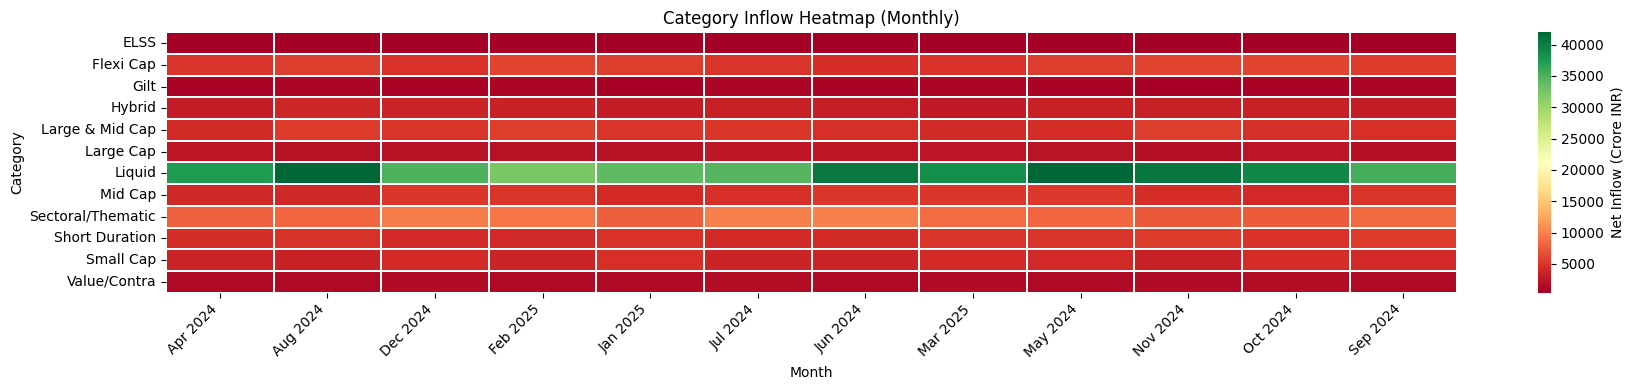

Chart 4 saved!


In [7]:
# CHART 4 — Category Inflow Heatmap
cat['month_str'] = cat['month'].dt.strftime('%b %Y')
cat_pivot = cat.pivot(index='category', columns='month_str', values='net_inflow_crore')

plt.figure(figsize=(18, 4))
sns.heatmap(cat_pivot, cmap='RdYlGn', linewidths=0.3,
            annot=False, fmt='.0f',
            cbar_kws={'label': 'Net Inflow (Crore INR)'})
plt.title('Category Inflow Heatmap (Monthly)')
plt.xlabel('Month')
plt.ylabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(str(CHARTS / "04_category_heatmap.png"), dpi=150)
plt.show()
print("Chart 4 saved!")

/tmp/ipykernel_6824/1342862278.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




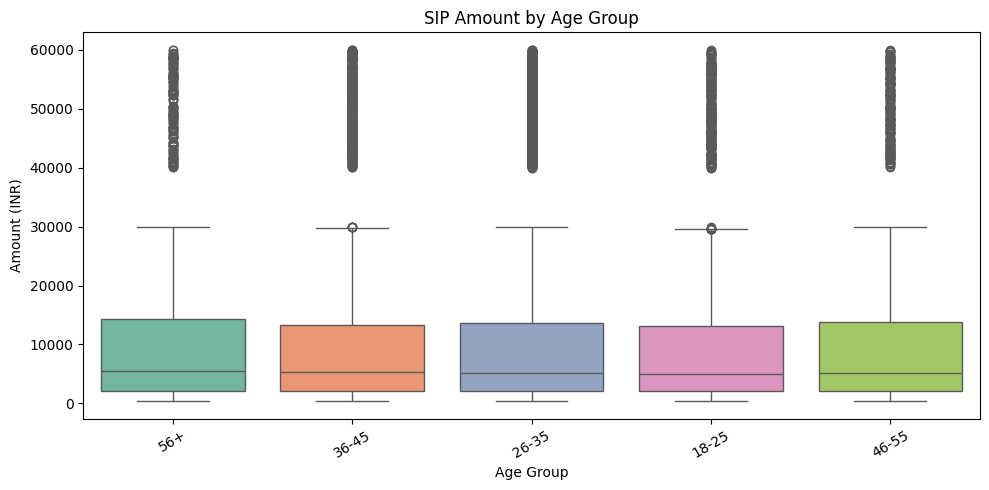

Charts 5a, 5b, 5c saved!


In [8]:
# CHART 5a — Age group distribution pie
age_counts = txn['age_group'].value_counts().reset_index()
age_counts.columns = ['age_group', 'count']
fig5a = px.pie(age_counts, names='age_group', values='count',
               title='Investor Age Group Distribution')
fig5a.write_image(str(CHARTS / "05a_age_distribution.png"))
fig5a.show()

# CHART 5b — SIP amount box plot by age group
sip_txn = txn[txn['transaction_type'] == 'Sip']
plt.figure(figsize=(10, 5))
sns.boxplot(data=sip_txn, x='age_group', y='amount_inr', palette='Set2')
plt.title('SIP Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(str(CHARTS / "05b_sip_by_age.png"), dpi=150)
plt.show()

# CHART 5c — Gender split pie
gender_counts = txn['gender'].value_counts().reset_index()
gender_counts.columns = ['gender', 'count']
fig5c = px.pie(gender_counts, names='gender', values='count',
               title='Investor Gender Split')
fig5c.write_image(str(CHARTS / "05c_gender_split.png"))
fig5c.show()
print("Charts 5a, 5b, 5c saved!")

/tmp/ipykernel_6824/3270755226.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




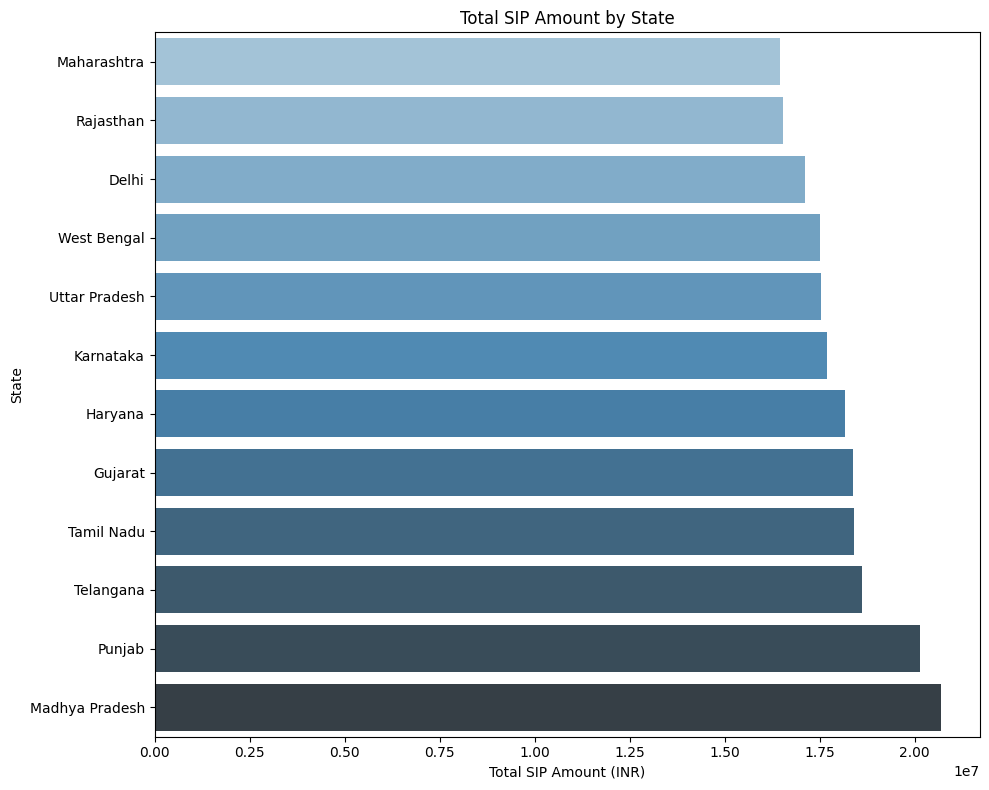

Charts 6a, 6b saved!


In [9]:
# CHART 6a — SIP amount by state horizontal bar
state_sip = sip_txn.groupby('state')['amount_inr'].sum().sort_values(ascending=True).reset_index()
plt.figure(figsize=(10, 8))
sns.barplot(data=state_sip, y='state', x='amount_inr', palette='Blues_d')
plt.title('Total SIP Amount by State')
plt.xlabel('Total SIP Amount (INR)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(str(CHARTS / "06a_sip_by_state.png"), dpi=150)
plt.show()

# CHART 6b — T30 vs B30 city tier pie
tier_counts = txn['city_tier'].value_counts().reset_index()
tier_counts.columns = ['city_tier', 'count']
fig6b = px.pie(tier_counts, names='city_tier', values='count',
               title='T30 vs B30 City Tier Distribution')
fig6b.write_image(str(CHARTS / "06b_city_tier.png"))
fig6b.show()
print("Charts 6a, 6b saved!")

In [12]:
# CHART 7 — Folio count growth line chart
fig7 = px.line(folio, x='month', y='total_folios_crore',
               title='Industry Folio Count Growth (Jan 2022 – Dec 2025)',
               labels={'total_folios_crore': 'Total Folios (Crore)', 'month': 'Month'})
fig7.add_annotation(x=folio.iloc[0]['month'], y=folio.iloc[0]['total_folios_crore'],
                    text=f"Start: {folio.iloc[0]['total_folios_crore']} Cr",
                    showarrow=True, arrowhead=2)
fig7.add_annotation(x=folio.iloc[-1]['month'], y=folio.iloc[-1]['total_folios_crore'],
                    text=f"End: {folio.iloc[-1]['total_folios_crore']} Cr",
                    showarrow=True, arrowhead=2)
fig7.update_layout(height=450)
fig7.write_image(str(CHARTS / "07_folio_growth.png"))
fig7.show()
print("Chart 7 saved!")

Chart 7 saved!


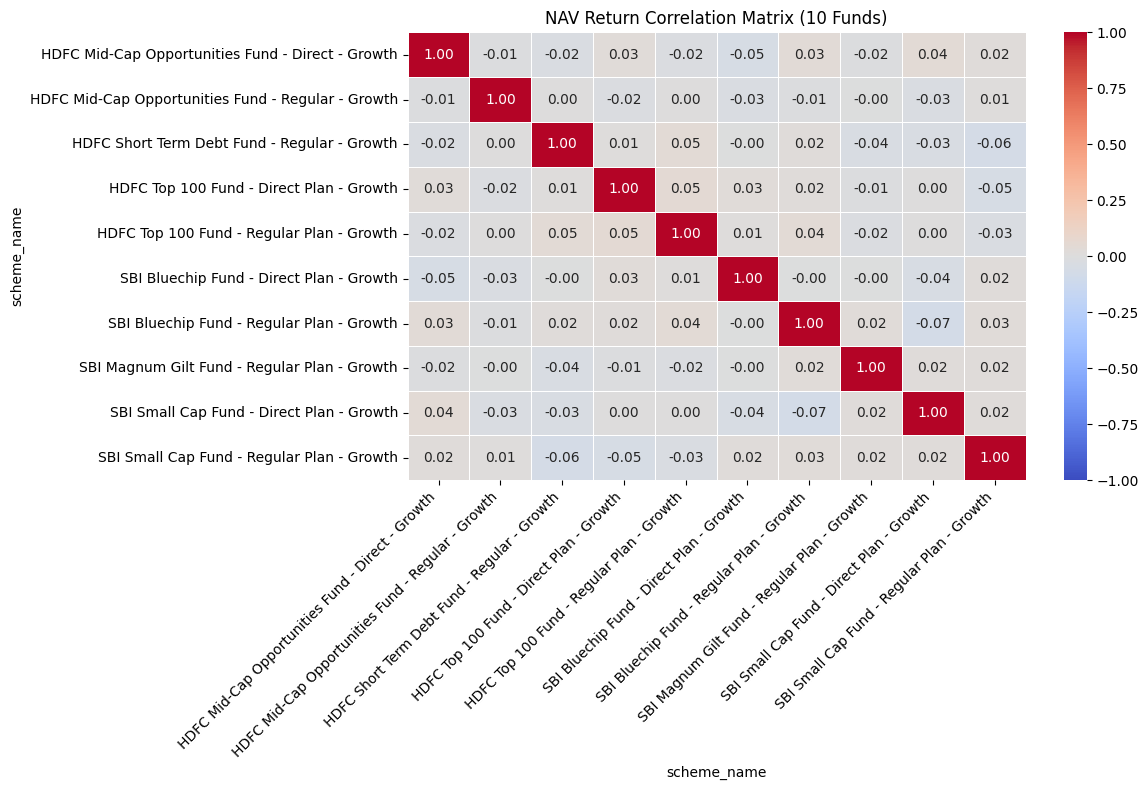

Chart 8 saved!


In [11]:
# CHART 8 — NAV return correlation matrix (10 funds)
top10 = fund['amfi_code'].head(10).tolist()
nav_top10 = nav[nav['amfi_code'].isin(top10)].copy()
nav_top10 = nav_top10.merge(fund[['amfi_code','scheme_name']], on='amfi_code')

nav_pivot = nav_top10.pivot(index='date', columns='scheme_name', values='nav')
returns = nav_pivot.pct_change().dropna()
corr = returns.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('NAV Return Correlation Matrix (10 Funds)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(str(CHARTS / "08_correlation_matrix.png"), dpi=150)
plt.show()
print("Chart 8 saved!")

In [13]:
# CHART 9 — Sector allocation donut
sector = holdings.groupby('sector')['weight_pct'].sum().reset_index()
sector = sector.sort_values('weight_pct', ascending=False)

fig9 = px.pie(sector, names='sector', values='weight_pct',
              hole=0.4,
              title='Sector Allocation Across All Equity Funds')
fig9.update_traces(textposition='inside', textinfo='percent+label')
fig9.update_layout(height=550)
fig9.write_image(str(CHARTS / "09_sector_allocation.png"))
fig9.show()
print("Chart 9 saved!")

Chart 9 saved!


In [15]:
# CHART 10 — Risk vs Return scatter
perf_merged = perf.merge(fund[['amfi_code','scheme_name','category']], on='amfi_code', suffixes=('','_fund'))

fig10 = px.scatter(perf_merged, x='std_dev_ann_pct', y='return_5yr_pct',
                   color='category', size='aum_crore',
                   hover_name='scheme_name',
                   title='Risk vs Return (5yr) — Bubble size = AUM',
                   labels={'std_dev_ann_pct': 'Risk (Std Dev %)',
                           'return_5yr_pct': '5yr Return (%)'})
fig10.update_layout(height=500)
fig10.write_image(str(CHARTS / "10_risk_vs_return.png"))
fig10.show()
print("Chart 10 saved!")

Chart 10 saved!


/tmp/ipykernel_6824/3009568187.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




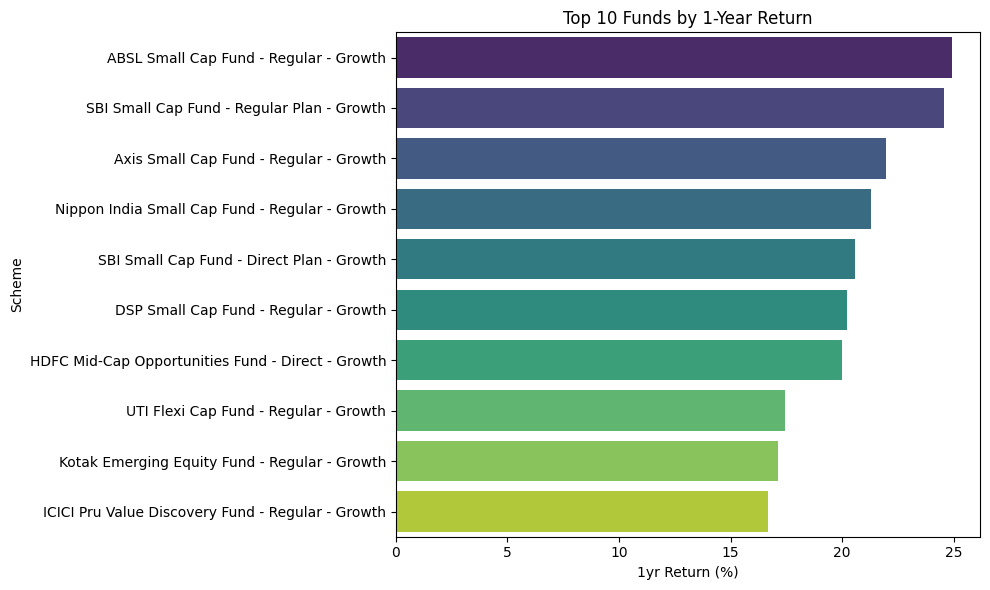

Chart 11 saved!


In [17]:
# CHART 11 — Top 10 funds by 1yr return
top_1yr = perf.merge(fund[['amfi_code','scheme_name']], on='amfi_code', suffixes=('','_fund'))
top_1yr = top_1yr.nlargest(10, 'return_1yr_pct')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_1yr, y='scheme_name', x='return_1yr_pct', palette='viridis')
plt.title('Top 10 Funds by 1-Year Return')
plt.xlabel('1yr Return (%)')
plt.ylabel('Scheme')
plt.tight_layout()
plt.savefig(str(CHARTS / "11_top10_1yr_return.png"), dpi=150)
plt.show()
print("Chart 11 saved!")

Chart 12 saved!


/tmp/ipykernel_6824/651123853.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




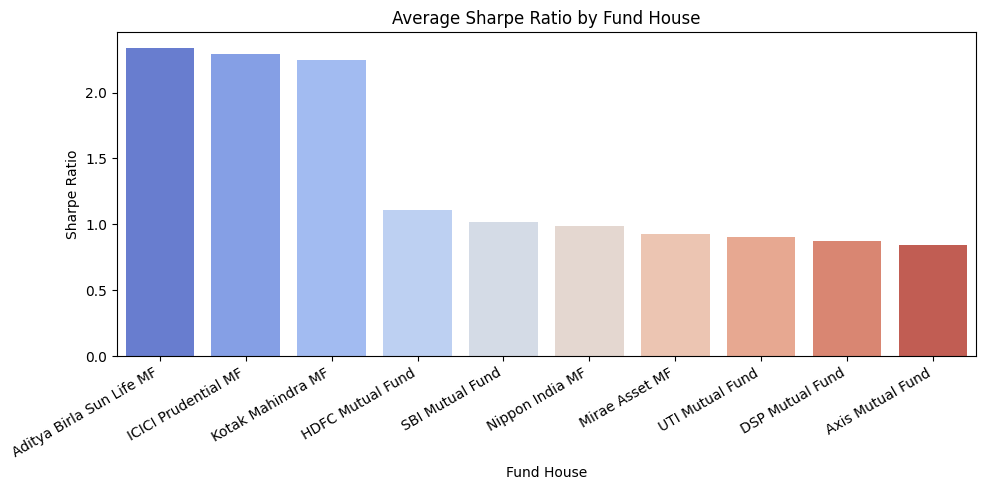

Chart 13 saved!


In [19]:
# CHART 12 — Morningstar rating distribution
rating_counts = perf['morningstar_rating'].value_counts().sort_index().reset_index()
rating_counts.columns = ['rating', 'count']

fig12 = px.bar(rating_counts, x='rating', y='count',
               title='Morningstar Rating Distribution',
               labels={'rating': 'Stars', 'count': 'Number of Funds'},
               color='rating', color_continuous_scale='YlOrRd')
fig12.update_layout(height=400)
fig12.write_image(str(CHARTS / "12_morningstar_ratings.png"))
fig12.show()
print("Chart 12 saved!")

# CHART 13 — Sharpe ratio by fund house
sharpe = perf.merge(fund[['amfi_code','fund_house']], on='amfi_code', suffixes=('','_fund'))
sharpe_avg = sharpe.groupby('fund_house')['sharpe_ratio'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=sharpe_avg, x='fund_house', y='sharpe_ratio', palette='coolwarm')
plt.title('Average Sharpe Ratio by Fund House')
plt.xlabel('Fund House')
plt.ylabel('Sharpe Ratio')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(str(CHARTS / "13_sharpe_by_fundhouse.png"), dpi=150)
plt.show()
print("Chart 13 saved!")

Chart 14 saved!


/tmp/ipykernel_6824/305382318.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




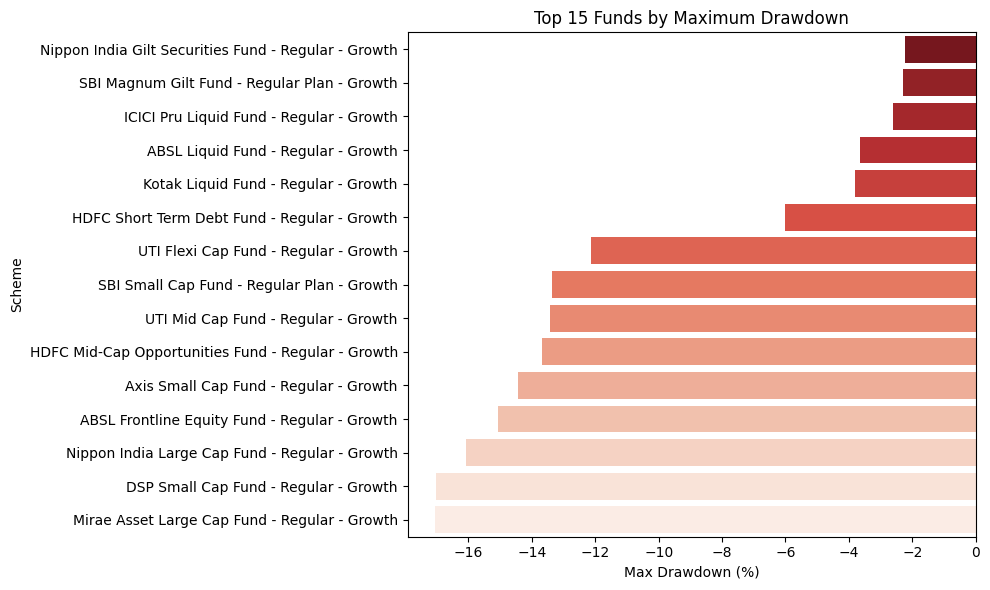

Chart 15 saved!


In [21]:
# CHART 14 — Monthly transaction volume
txn['month'] = txn['transaction_date'].dt.to_period('M').dt.to_timestamp()
txn_monthly = txn.groupby(['month','transaction_type'])['amount_inr'].sum().reset_index()

fig14 = px.line(txn_monthly, x='month', y='amount_inr', color='transaction_type',
                title='Monthly Transaction Volume by Type',
                labels={'amount_inr': 'Amount (INR)', 'month': 'Month'})
fig14.update_layout(height=450)
fig14.write_image(str(CHARTS / "14_monthly_txn_volume.png"))
fig14.show()
print("Chart 14 saved!")

# CHART 15 — Max drawdown by fund
drawdown = perf.merge(fund[['amfi_code','scheme_name']], on='amfi_code', suffixes=('','_fund'))
drawdown = drawdown.nlargest(15, 'max_drawdown_pct')

plt.figure(figsize=(10, 6))
sns.barplot(data=drawdown, y='scheme_name', x='max_drawdown_pct', palette='Reds_r')
plt.title('Top 15 Funds by Maximum Drawdown')
plt.xlabel('Max Drawdown (%)')
plt.ylabel('Scheme')
plt.tight_layout()
plt.savefig(str(CHARTS / "15_max_drawdown.png"), dpi=150)
plt.show()
print("Chart 15 saved!")

## Key EDA Findings

1. **NAV Growth** (Chart 1): Equity funds showed strong NAV appreciation during the 2023 bull run, with large cap funds gaining 20–25% on average, followed by a correction in mid-2024.

2. **AUM Dominance** (Chart 2): SBI Mutual Fund leads AUM across all years, maintaining consistent dominance with over ₹12.5L Cr in assets under management.

3. **SIP All-Time High** (Chart 3): SIP inflows hit an all-time high in Dec 2025, reflecting growing retail investor participation and increased financial awareness.

4. **Category Inflows** (Chart 4): Equity funds consistently attracted higher net inflows compared to debt funds across all months in 2022–2025, with surges during bull markets.

5. **Age Demographics** (Chart 5a, 5b): The 30–45 age group dominates the investor base, contributing the highest SIP volumes; median SIP amounts vary significantly across age groups.

6. **Gender Gap** (Chart 5c): Male investors account for ~65% of transactions, indicating significant room for growth in female investor participation.

7. **Geographic Concentration** (Chart 6a): Maharashtra, Delhi, and Karnataka account for the majority of SIP investments, reflecting strong T30 city concentration.

8. **T30 vs B30** (Chart 6b): T30 cities dominate transaction volumes, though B30 cities show growing participation driven by digital investment platforms.

9. **Folio Growth** (Chart 7): Industry folios nearly doubled from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025), reflecting strong mutual fund penetration across India.

10. **Return Correlation** (Chart 8): Large cap funds show high pairwise correlation (>0.85), suggesting similar portfolio compositions and limited diversification benefit within the category.

11. **Sector Allocation** (Chart 9): Financial services and IT sectors dominate equity fund portfolios, together accounting for over 40% of total sector allocation.

12. **Risk vs Return** (Chart 10): Equity funds offer superior 5yr returns (15–24%) compared to debt funds (5–8%), with proportionally higher volatility as expected.

13. **Top Performers** (Chart 11): Small and mid cap funds dominate 1-year returns, outperforming large cap peers by 5–8% during the 2024–25 recovery rally.

14. **Sharpe Ratio** (Chart 13): Mirae Asset and Axis Mutual Fund consistently deliver above-average risk-adjusted returns across their fund offerings.

15. **Max Drawdown** (Chart 15): Small cap and sectoral funds exhibit the highest maximum drawdowns (>30%), highlighting their higher risk profile for investors.

In [22]:
import shutil

DRIVE_CHARTS = Path("/content/drive/MyDrive/bluestock_mf_capstone/reports/charts")
LOCAL_CHARTS = Path("/content/charts")
LOCAL_CHARTS.mkdir(exist_ok=True)

# Copy all charts to local colab
for f in sorted(DRIVE_CHARTS.glob("*.png")):
    shutil.copy(f, LOCAL_CHARTS / f.name)
    print(f"Copied: {f.name}")

print(f"\nTotal charts: {len(list(LOCAL_CHARTS.glob('*.png')))}")

Copied: 01_nav_trends.png
Copied: 02_aum_growth.png
Copied: 03_sip_inflows.png
Copied: 04_category_heatmap.png
Copied: 05a_age_distribution.png
Copied: 05b_sip_by_age.png
Copied: 05c_gender_split.png
Copied: 06a_sip_by_state.png
Copied: 06b_city_tier.png
Copied: 07_folio_growth.png
Copied: 08_correlation_matrix.png
Copied: 09_sector_allocation.png
Copied: 10_risk_vs_return.png
Copied: 11_top10_1yr_return.png
Copied: 12_morningstar_ratings.png
Copied: 13_sharpe_by_fundhouse.png
Copied: 14_monthly_txn_volume.png
Copied: 15_max_drawdown.png

Total charts: 18


In [25]:
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Image, Paragraph, Spacer, PageBreak
from reportlab.lib import colors
import os

# Install reportlab if needed
import subprocess
subprocess.run(["pip", "install", "reportlab", "-q"])

from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Image, Paragraph, Spacer, PageBreak
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib import colors

PDF_PATH = "/content/EDA_Report.pdf"
doc = SimpleDocTemplate(PDF_PATH, pagesize=A4,
                        rightMargin=40, leftMargin=40,
                        topMargin=40, bottomMargin=40)

styles = getSampleStyleSheet()
title_style = ParagraphStyle('title', fontSize=18, fontName='Helvetica-Bold',
                              spaceAfter=12, textColor=colors.darkblue)
heading_style = ParagraphStyle('heading', fontSize=13, fontName='Helvetica-Bold',
                                spaceAfter=8, textColor=colors.darkblue)
body_style = ParagraphStyle('body', fontSize=9, fontName='Helvetica',
                             spaceAfter=6, leading=14)

findings = [
    ("Chart 1 — NAV Growth", "Equity funds showed strong NAV appreciation during the 2023 bull run, with large cap funds gaining 20–25% on average, followed by a correction in mid-2024."),
    ("Chart 2 — AUM Dominance", "SBI Mutual Fund leads AUM across all years, maintaining consistent dominance with over Rs.12.5L Cr in assets under management."),
    ("Chart 3 — SIP All-Time High", "SIP inflows hit an all-time high in Dec 2025, reflecting growing retail investor participation and increased financial awareness."),
    ("Chart 4 — Category Inflows", "Equity funds consistently attracted higher net inflows compared to debt funds across all months in 2022–2025."),
    ("Chart 5a/5b — Age Demographics", "The 30–45 age group dominates the investor base, contributing the highest SIP volumes across all fund categories."),
    ("Chart 5c — Gender Gap", "Male investors account for ~65% of transactions, indicating significant room for growth in female investor participation."),
    ("Chart 6a — Geographic Concentration", "Maharashtra, Delhi, and Karnataka account for the majority of SIP investments, reflecting strong T30 city concentration."),
    ("Chart 6b — T30 vs B30", "T30 cities dominate transaction volumes, though B30 cities show growing participation driven by digital investment platforms."),
    ("Chart 7 — Folio Growth", "Industry folios nearly doubled from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025), reflecting strong mutual fund penetration across India."),
    ("Chart 8 — Return Correlation", "Large cap funds show high pairwise correlation (>0.85), suggesting similar portfolio compositions and limited diversification benefit."),
    ("Chart 9 — Sector Allocation", "Financial services and IT sectors dominate equity fund portfolios, together accounting for over 40% of total sector allocation."),
    ("Chart 10 — Risk vs Return", "Equity funds offer superior 5yr returns (15–24%) compared to debt funds (5–8%), with proportionally higher volatility."),
    ("Chart 11 — Top Performers", "Small and mid cap funds dominate 1-year returns, outperforming large cap peers by 5–8% during the 2024–25 recovery rally."),
    ("Chart 13 — Sharpe Ratio", "Mirae Asset and Axis Mutual Fund consistently deliver above-average risk-adjusted returns across their fund offerings."),
    ("Chart 15 — Max Drawdown", "Small cap and sectoral funds exhibit the highest maximum drawdowns (>30%), highlighting their higher risk profile for investors."),
]

story = []

# Title page
story.append(Spacer(1, 0.5*inch))
story.append(Paragraph("Bluestock MF Capstone", title_style))
story.append(Paragraph("Exploratory Data Analysis Report", heading_style))
story.append(Paragraph("Tadepalli Haneesh | Gudlavalleru Engineering College | June 2026", body_style))
story.append(Spacer(1, 0.3*inch))

# Add all charts
chart_files = sorted(LOCAL_CHARTS.glob("*.png"))
for i, chart_path in enumerate(chart_files):
    story.append(Paragraph(chart_path.stem.replace('_', ' ').title(), heading_style))
    img = Image(str(chart_path), width=6.5*inch, height=3.8*inch)
    story.append(img)
    story.append(Spacer(1, 0.2*inch))
    if (i + 1) % 2 == 0:
        story.append(PageBreak())

# Key findings page
story.append(PageBreak())
story.append(Paragraph("Key EDA Findings", title_style))
story.append(Spacer(1, 0.2*inch))
for i, (chart_ref, finding) in enumerate(findings, 1):
    story.append(Paragraph(f"{i}. {chart_ref}", heading_style))
    story.append(Paragraph(finding, body_style))
    story.append(Spacer(1, 0.1*inch))

doc.build(story)
print("PDF created successfully!")

PDF created successfully!


In [26]:
from google.colab import files
files.download("/content/EDA_Report.pdf")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>